# Weather Data Analysis (Extra Credit)
This tiny EDA notebook reads the CSV file generated by our pipeline and displays some basic plots.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the CSV file
df = pd.read_csv('data/processed/weather_data.csv')

# Convert the date string to a datetime object for better scaling on the X-axis
df['date'] = pd.to_datetime(df['date'])

# Since the pipeline appends new rows on every run, we drop duplicate dates 
# and sort them so our graph lines don't bounce backward!
df = df.drop_duplicates(subset=['city', 'date']).sort_values('date')

df.head()

,city,date,temp_max,temp_min,precipitation,wind_speed_max,precip_prob_max
0,Tallahassee,2026-03-31,28.3,16.6,0.0,NaN,NaN
14,Orlando,2026-03-31,28.8,16.2,0.0,NaN,NaN
7,Miami,2026-03-31,26.8,21.1,0.0,NaN,NaN
1,Tallahassee,2026-04-01,27.9,16.5,0.0,NaN,NaN
15,Orlando,2026-04-01,26.6,15.2,0.0,NaN,NaN


## Max Temperature Over Time
This line chart shows how the maximum temperature fluctuates for our tracked cities.

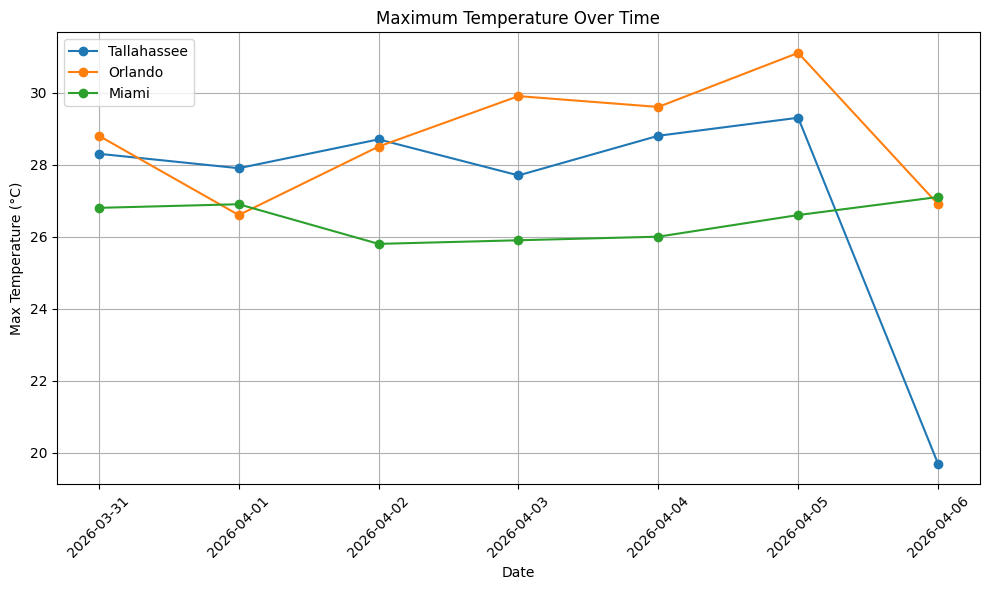

In [11]:
plt.figure(figsize=(10, 6))

for city in df['city'].unique():
    city_data = df[df['city'] == city]
    plt.plot(city_data['date'], city_data['temp_max'], marker='o', label=city)

plt.title('Maximum Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Max Temperature (\u00b0C)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Precipitation Over Time
Here we can view the daily precipitation sums mapped out.

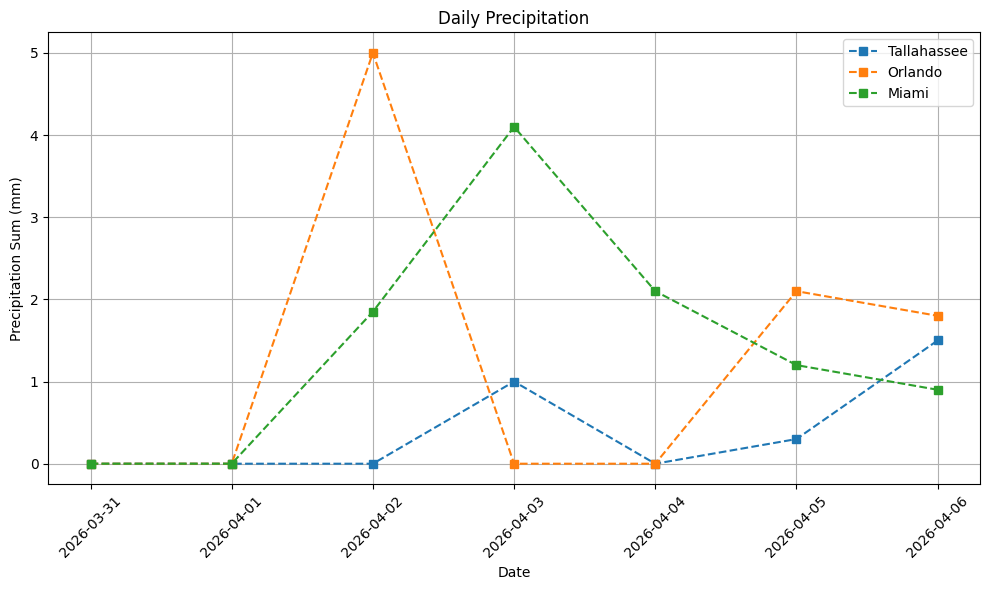

In [12]:
plt.figure(figsize=(10, 6))

for city in df['city'].unique():
    city_data = df[df['city'] == city]
    plt.plot(city_data['date'], city_data['precipitation'], marker='s', linestyle='--', label=city)

plt.title('Daily Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation Sum (mm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()